# PlantVillage Disease Classification

<p align="right">
Run Time: ~20 minutes with training included / ~15 minutes with training skipped
</p>

This notebook walks through the complete pipeline to train, quantize, convert, and
benchmark an AkidaNet model on the **PlantVillage** dataset for Akida 1 hardware.

PlantVillage contains 54,303 images of healthy and diseased plant leaves across
38 categories (14 crop species × multiple disease types plus healthy variants).
The task is a 38-class image classification problem: given a 224×224 RGB image of
a leaf, identify the crop species and disease (or healthy state).

The pipeline follows the standard Akida workflow:
1. Train a float model
2. Post-training quantization (PTQ)
3. Quantization-aware training (QAT) fine-tuning
4. Conversion to Akida `.fbz` format
5. Hardware evaluation and benchmarking

In [2]:
import os
import numpy as np
import tensorflow as tf

import pooch
from tf_keras.utils import set_random_seed

from cnn2snn import load_quantized_model

DATA_PATH = './data/plant_village'
MODELS_DIR = './models/'
os.makedirs(MODELS_DIR, exist_ok=True)

RUN_FLOAT_TRAINING = True
RUN_QAT_TRAINING = True

SEED = 42

# Must be called before any TF ops to make GPU ops (conv backward passes,
# bilinear resize, etc.) deterministic. Has a small throughput cost.
tf.config.experimental.enable_op_determinism()

## Dataset

The **PlantVillage** dataset is loaded via TensorFlow Datasets (`plant_village`).
On the first run, TFDS will automatically download and prepare the dataset to
`DATA_PATH`. Subsequent runs read from the local cache.

The dataset is split 80/10/10 (train/val/test). Images are resized from variable
original sizes to **224 × 224 RGB** and delivered as uint8 pixel values (0–255).
Training applies random horizontal flip, brightness jitter, and contrast jitter
for regularisation.

To pre-download without training, run:
```bash
python -c "import tensorflow_datasets as tfds; tfds.load('plant_village', data_dir='./data/plant_village')"
```

In [3]:
from plant_village_data import get_data

INPUT_SHAPE = (224, 224, 3)
BATCH_SIZE = 32

train_ds, val_ds, test_ds = get_data(DATA_PATH, input_shape=INPUT_SHAPE, batch_size=BATCH_SIZE, seed=SEED)
print('Datasets ready.')

Datasets ready.


2026-06-26 15:34:49.199092: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## Model

The model is based on **AkidaNet** (`akida_models.akidanet_imagenet`) with:
- Width multiplier **alpha = 0.5** — provides sufficient capacity for 38 classes
  while remaining efficient on Akida 1 hardware
- Input resolution **224 × 224 RGB**
- **38-class** classification head (replacing the ImageNet top)
- **Input scaling (255, 0)** built into the model — the pipeline delivers raw
  uint8 pixel values and the model normalises them internally

AkidaNet is specifically designed for Akida hardware: it uses only operations
that map efficiently to Akida Neural Processors (NPs), including depthwise
separable convolutions and ReLU activations.

In [4]:
from plant_village_model import build_plant_village_model

model = build_plant_village_model(seed=SEED)
model.summary()

/home/dmclelland/miniconda3/envs/ak2191/lib/python3.10/site-packages/akida_models/model_io.py:147: UserWarning: Model akidanet_imagenet_224_alpha_50.h5 has been trained with akida_models 1.1.10 which is the last version supporting 1.0 models training. Continuing execution.
  warnings.warn(f'Model {model_name_v1} has been trained with akida_models 1.1.10 which is '


Model: "akidanet_plantvillage"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input (InputLayer)          [(None, 224, 224, 3)]     0         
                                                                 
 rescaling (Rescaling)       (None, 224, 224, 3)       0         
                                                                 
 conv_0 (Conv2D)             (None, 112, 112, 16)      432       
                                                                 
 conv_0/BN (BatchNormalizat  (None, 112, 112, 16)      64        
 ion)                                                            
                                                                 
 conv_0/relu (ReLU)          (None, 112, 112, 16)      0         
                                                                 
 conv_1 (Conv2D)             (None, 112, 112, 32)      4608      
                                             

## Float Training

The model is trained in full float32 precision for 10 epochs using the Adam
optimiser and sparse categorical cross-entropy loss (with `from_logits=True`,
since the model head outputs raw logits rather than softmax probabilities).

The learning rate follows an **exponential decay** schedule, starting at `1e-3`
and decaying to approximately `1e-5` by the final epoch.

Set `RUN_FLOAT_TRAINING = True` above to train from scratch. Otherwise, the
cell below downloads a pre-trained float model directly from BrainChip servers.

In [ ]:
from plant_village_train import train_plant_village

if RUN_FLOAT_TRAINING:
    train_plant_village(
        model, train_ds, val_ds,
        epochs=10,
        learning_rate=1e-3,
        seed=SEED)
    model.save(
        MODELS_DIR + 'akidanet_plant_village.h5',
        include_optimizer=False)
    print('Float model saved.')
else:
    float_model_path = 'pretrained_models/akidanet_plant_village.h5'
    model = load_quantized_model(float_model_path)
    model.compile(metrics=['accuracy'])

Epoch 1/10


I0000 00:00:1782398222.856022 1181555 cuda_dnn.cc:529] Loaded cuDNN version 90300


1358/1358 [==============================] - 25s 16ms/step - loss: 0.4369 - accuracy: 0.9187 - val_loss: 0.5182 - val_accuracy: 0.8921 - lr: 0.0010
Epoch 2/10
1358/1358 [==============================] - 22s 16ms/step - loss: 0.2350 - accuracy: 0.9787 - val_loss: 0.3137 - val_accuracy: 0.9543 - lr: 6.3096e-04
Epoch 3/10
1358/1358 [==============================] - 24s 17ms/step - loss: 0.1989 - accuracy: 0.9884 - val_loss: 0.1943 - val_accuracy: 0.9890 - lr: 3.9811e-04
Epoch 4/10
1358/1358 [==============================] - 22s 16ms/step - loss: 0.1790 - accuracy: 0.9931 - val_loss: 0.1817 - val_accuracy: 0.9906 - lr: 2.5119e-04
Epoch 5/10
1358/1358 [==============================] - 23s 16ms/step - loss: 0.1612 - accuracy: 0.9967 - val_loss: 0.1739 - val_accuracy: 0.9930 - lr: 1.5849e-04
Epoch 6/10
1358/1358 [==============================] - 22s 16ms/step - loss: 0.1507 - accuracy: 0.9984 - val_loss: 0.1588 - val_accuracy: 0.9948 - lr: 1.0000e-04
Epoch 7/10
1358/1358 [===============

/home/dmclelland/miniconda3/envs/ak2191/lib/python3.10/site-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [ ]:
_, float_acc = model.evaluate(test_ds, verbose=1)
print(f'Float accuracy: {float_acc:.4f}')

170/170 [==============================] - 1s 8ms/step - loss: 0.1446 - accuracy: 0.9961
Float accuracy: 0.9961


## Quantization

Post-training quantization (PTQ) via `cnn2snn.quantize` converts the model
to fixed-point arithmetic:
- **Input**: 8-bit (`-i 8`)
- **Weights**: 4-bit (`-w 4`)
- **Activations**: 4-bit (`-a 4`)

4-bit quantization must be used to be compatible with Akida 1 hardware. Note though that
the first layer (both its inputs and weights) can be 8-bit.

In [ ]:
import cnn2snn

quantized_model = cnn2snn.quantize(
    model,
    input_weight_quantization=8,
    weight_quantization=4,
    activ_quantization=4)
print('Model quantized to i8/w4/a4.')

Model quantized to i8/w4/a4.


Quantizing a model after training like this is referred to as Post-Training
Quantization (PTQ). It can slightly reduce accuracy (especially at 4-bits as
here) because the model was trained with continuous weights but is now 
evaluated with discrete values.

In [ ]:
quantized_model.compile(metrics=['accuracy'])
_, ptq_acc = quantized_model.evaluate(test_ds, verbose=1)
print(f'PTQ accuracy: {ptq_acc:.4f}')

170/170 [==============================] - 3s 16ms/step - loss: 0.3998 - accuracy: 0.6818
PTQ accuracy: 0.6818


## Quantization-Aware Training (QAT)

We can run Quantization Aware Training (QAT) to recover most of the drop in 
accuracy. QAT fine-tunes the quantized model for a few epochs (here, 2) at a
reduced learning rate (`1e-4`). Note that, although it can sound intimidating,
QAT with BrainChip's quantization tools is no more complex than simply sending
the quantized model back through the same training pipeline that was used to
prepare the float model in the first place.

Set `RUN_QAT_TRAINING = True` above to run QAT locally. Otherwise, the cell
below downloads a pre-trained QAT model from BrainChip servers.

In [ ]:
if RUN_QAT_TRAINING:
    # We refetch the dataset, only to ensure reproducibility against the non-notebook pipeline.
    # This resets the shuffle seed on the training data
    train_ds, val_ds, test_ds = get_data(DATA_PATH, input_shape=INPUT_SHAPE, batch_size=BATCH_SIZE, seed=SEED)
    train_plant_village(
        quantized_model, train_ds, val_ds,
        epochs=2,
        learning_rate=1e-4)
    quantized_model.save(
        MODELS_DIR + 'akidanet_plant_village_qat.h5',
        include_optimizer=False)
    print('QAT model saved.')
else:
    qat_model_path = 'pretrained_models/akidanet_plant_village_qat.h5'
    quantized_model = load_quantized_model(qat_model_path)
    quantized_model.compile(metrics=['accuracy'])

Epoch 1/2
1358/1358 [==============================] - 44s 31ms/step - loss: 0.4423 - accuracy: 0.9841 - val_loss: 0.4188 - val_accuracy: 0.9902 - lr: 1.0000e-04
Epoch 2/2
1358/1358 [==============================] - 42s 30ms/step - loss: 0.3885 - accuracy: 0.9990 - val_loss: 0.4025 - val_accuracy: 0.9937 - lr: 1.0000e-05
QAT model saved.


/home/dmclelland/miniconda3/envs/ak2191/lib/python3.10/site-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [ ]:
_, qat_acc = quantized_model.evaluate(test_ds, verbose=1)
print(f'QAT accuracy: {qat_acc:.4f}')

170/170 [==============================] - 3s 16ms/step - loss: 0.4023 - accuracy: 0.9945
QAT accuracy: 0.9945


## Conversion to Akida Format

`cnn2snn.convert` compiles the quantized Keras model into an Akida `.fbz`
model that can be loaded and executed directly on AKD1500 hardware.
The converter verifies hardware compatibility and maps each layer to its
corresponding Akida primitive.

In [ ]:
akida_model = cnn2snn.convert(quantized_model)

akida_model_path = os.path.join(MODELS_DIR, 'akidanet_plant_village_qat.fbz')
akida_model.save(akida_model_path)
print(f'Akida model saved to {akida_model_path}')
akida_model.summary()

Akida model saved to ./models/akidanet_plant_village_qat.fbz
                 Model Summary                  
________________________________________________
Input shape    Output shape  Sequences  Layers
[224, 224, 3]  [1, 1, 38]    1          16    
________________________________________________

____________________________________________________________
Layer (type)              Output shape    Kernel shape    

============= SW/conv_0-predictions (Software) =============

conv_0 (InputConv.)       [112, 112, 16]  (3, 3, 3, 16)   
____________________________________________________________
conv_1 (Conv.)            [112, 112, 32]  (3, 3, 16, 32)  
____________________________________________________________
conv_2 (Conv.)            [56, 56, 64]    (3, 3, 32, 64)  
____________________________________________________________
conv_3 (Conv.)            [56, 56, 64]    (3, 3, 64, 64)  
____________________________________________________________
separable_4 (Sep.Conv.)   [28, 28,

## Evaluation of Akida Model

We now run evaluation through the Akida model, to check that accuracy is 
comparable to that obtained from the quantized tf_keras model. If an Akida 1
hardware device is connected, it will be used for inference; if not, the
code will fall back to using the software backend: this delivers a
bit-accurate simulation of the results that will be obtained when running
the model on hardware. Let's run that check before going any further

### Check for a connected Akida hardware device

We can use the `akida.devices()` function to detect connected hardware devices.
That returns a list - if it's empty, there were no hardware devices. Otherwise, 
typically we'd only have a single Akida device connected on a given machine, 
and we can just select the first (and only) device returned.

In [ ]:
import akida
devices = akida.devices()
if len(devices)>0:
    # Hardware is available
    device = devices[0]
else:
    # Hardware is not available
    device = None

In the present case, we want to be a bit more careful and ensure that the
device is the right version for the model we want to test (here, Akida IP
version 1). We'll import a local function to do that - check out the details 
if interested

In [ ]:
from brainchip_utils.hardware_utils import get_akida_device

# Load the Akida model
akida_model = akida.Model(akida_model_path)
# Look for a matching hardware device
device = get_akida_device(target_version = akida_model.ip_version)
if device is not None:
    akida_model.map(device, mode=akida.MapMode.Minimal, hw_only=True)

Target Akida device found


### Run Evaluation on Akida

The Akida runtime cannot consume `tf.data.Dataset` objects directly, rather
it expects a 4D numpy array (n, h, w, c) in uint8 format. So we
iterate over validation batches manually.

The model output tensor has shape `(B, 1, 1, C)` which is squeezed to 
`(B, C)` before taking the class argmax.

In [ ]:
from tqdm import tqdm

labels_all = []
logits_all = []
for batch, label_batch in tqdm(test_ds, desc="Evaluating on Akida"):
    if not isinstance(batch, np.ndarray):
        batch = batch.numpy()

    logits_batch = akida_model.predict(batch, batch_size=1)

    logits_batch = logits_batch.squeeze(axis=(1, 2))
    labels_all.append(label_batch)
    logits_all.append(logits_batch)

labels_all = np.concatenate(labels_all)
logits_all = np.concatenate(logits_all)
preds = np.argmax(logits_all, axis=1)

akida_acc = float(np.mean(preds == np.array(labels_all)))
print(f'Akida accuracy: {akida_acc:.4f}')

Evaluating on Akida: 100%|██████████| 170/170 [08:42<00:00,  3.07s/it]

Akida accuracy: 0.9943


### Activation Sparsity

Akida hardware skips computation for zero-valued activations, so activation
sparsity directly reduces both energy consumption and inference latency.
Below we measure per-layer sparsity on a 1024-sample calibration batch drawn
from the training set.

In [ ]:
from akida_models.sparsity import compute_sparsity
from brainchip_utils.plot_utils import pretty_print_sparsity
from plant_village_data import get_samples

NUM_SAMPLES = 100

samples = get_samples(DATA_PATH, input_shape=INPUT_SHAPE, num_samples=NUM_SAMPLES)
sparsity_dict = compute_sparsity(akida_model, samples=samples)
pretty_print_sparsity(sparsity_dict)

2026-06-25 17:10:17.466278: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



Layer            Sparsity
-------------------------
conv_0            31.83%
conv_1            51.38%
conv_2            57.84%
conv_3            43.97%
separable_4       41.81%
separable_5       64.18%
separable_6       44.12%
separable_7       56.34%
separable_8       62.88%
separable_9       67.96%
separable_10      76.68%
separable_11      62.30%
separable_12      88.24%
separable_13      63.78%
fc_1              59.94%
predictions        0.03%
-------------------------
Mean              54.58%


## Hardware Benchmark

**These cells require a physical AKD1500 device to be connected.** If `device is
None` (reported in the evaluation section above), skip ahead to the Summary.

Akida is an event-driven architecture: computations scale with the number of
non-zero activations, not with tensor size. That means benchmark results are
*input-dependent* — random or synthetic data would give artificially fast or
slow timings. The `samples` array loaded above (real images from the validation
split) is therefore the correct input to use here.

### Simple Benchmark

The simplest way to time an Akida model is to call `forward` in a loop and
read back two clocks after each inference:

- **System clock** (`time.perf_counter_ns`) — wall time including Python and
  USB/PCIe transfer overhead.
- **On-chip clock** (`akida_model.metrics['inference_clk']`) — raw clock cycles
  counted by the AKD1500 itself. Dividing by the 400 MHz core frequency gives
  the pure compute time.

The two numbers should agree closely; a large divergence would indicate a
transfer or driver bottleneck.

In [ ]:
import time

CLOCK_FREQUENCY = 400e6  # 400 MHz for AKD1500

if device is not None:
    akida_model.map(device, mode=akida.MapMode.Minimal, hw_only=True)

    inf_clks = []
    inf_times = []
    for i in range(len(samples)):
        start_t = time.perf_counter_ns()
        akida_model.forward(samples[i:i+1])
        inf_times.append(time.perf_counter_ns() - start_t)
        inf_clks.append(akida_model.metrics['inference_clk'])

    mean_inf_clk = np.mean(inf_clks) / CLOCK_FREQUENCY * 1e3  # cycles → ms
    mean_inf_time = np.mean(inf_times) * 1e-6                  # ns → ms
    print(f'Mean inference time (system clock):      {mean_inf_time:.3f} ms')
    print(f'Mean on-chip time (chip clock cycles):   {mean_inf_clk:.3f} ms')

Mean inference time (system clock):      95.999 ms
Mean on-chip time (chip clock cycles):   91.048 ms


### Full Model Benchmark

The loop above is clear, but it misses two things: power consumption and a
comparison between mapping modes. `full_model_benchmark` from
[brainchip_utils/hardware_utils.py](../../../brainchip_utils/hardware_utils.py)
runs the same timed loop while also coordinating optional INA219 power
measurement in a separate process. It sweeps both `MapMode.Minimal` (fewest
NPs, lowest power) and `MapMode.AllNps` (all NPs, maximum parallelism) so the
trade-off is visible. The multiprocessing and power-meter wiring are
non-trivial and not of interest to most users — consult the source if needed.

In [ ]:
from brainchip_utils.hardware_utils import full_model_benchmark, get_mapping_stats
from brainchip_utils.plot_utils import plot_full_model_results

if device is not None:
    map_modes = ['Minimal', 'AllNps']
    POWER_REPEATS = 10
    full_results = {}
    for mm in map_modes:
        map_mode = getattr(akida.MapMode, mm)
        print(f'Running full-model benchmark (MapMode={mm}, {POWER_REPEATS} repeat(s))...')
        full_results[mm] = full_model_benchmark(
            akida_model, device, samples, map_mode=map_mode, repeats=POWER_REPEATS)

        akida_model.map(device, mode=map_mode)
        num_nps, num_passes, num_sequences = get_mapping_stats(akida_model)
        full_results[mm]['num_nps'] = num_nps
        full_results[mm]['num_passes'] = num_passes
        print(f'  Mapping: {num_nps} NP(s), {num_passes} pass(es), {num_sequences} sequence(s)')
        if num_sequences > 1:
            print('WARNING: model not completely mapped to hardware')

Running full-model benchmark (MapMode=Minimal, 10 repeat(s))...
Checking I2C power measurement hardware...
  I2C INA sensor detected — power measurement enabled.
  Supply voltage: 0.805 V
  Power measurement active.
  Repeat 1/10: recording floor (1.0 s)...
  Repeat 1/10 done.
  Repeat 2/10: recording floor (1.0 s)...
  Repeat 2/10 done.
  Repeat 3/10: recording floor (1.0 s)...
  Repeat 3/10 done.
  Repeat 4/10: recording floor (1.0 s)...
  Repeat 4/10 done.
  Repeat 5/10: recording floor (1.0 s)...
  Repeat 5/10 done.
  Repeat 6/10: recording floor (1.0 s)...
  Repeat 6/10 done.
  Repeat 7/10: recording floor (1.0 s)...
  Repeat 7/10 done.
  Repeat 8/10: recording floor (1.0 s)...
  Repeat 8/10 done.
  Repeat 9/10: recording floor (1.0 s)...
  Repeat 9/10 done.
  Repeat 10/10: recording floor (1.0 s)...
  Power process: 7139 ok, 0 errors
  Repeat 10/10 done.

  Mean inference time:    95.906 ms  (σ=1.078 ms)
  Mean on-chip time:      91.047 ms  (36418849 clocks)
  Total inferences ru

The plot below shows one column per map mode: a power trace (if a power meter
was connected) and the hardware mapping layout.

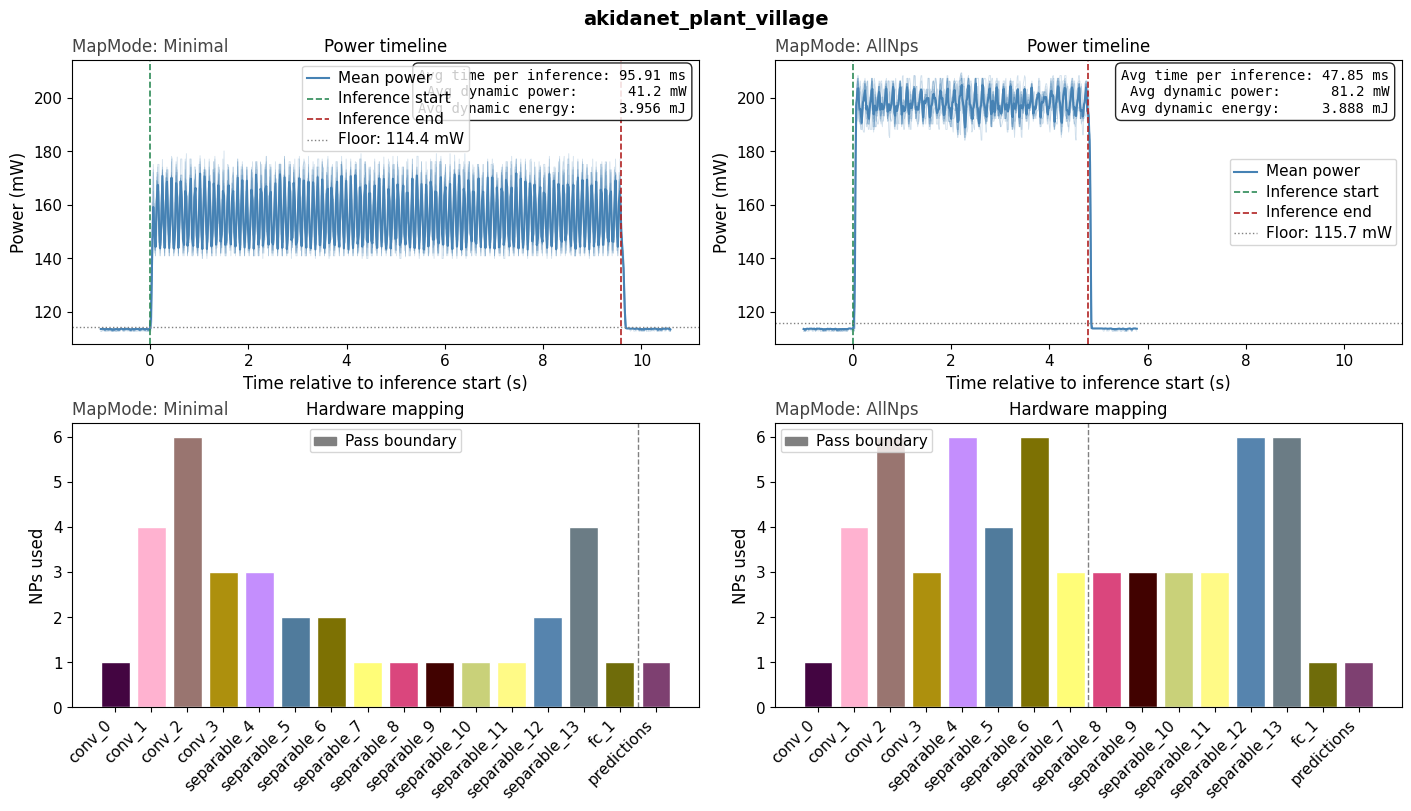

In [ ]:
if device is not None:
    plot_full_model_results(full_results, akida_model, device,
                            model_name='akidanet_plant_village',
                            savepath='benchmark_results_full.png')

### Per-Layer Benchmark

Full-model timing tells us the total cost but not where time is spent.
`per_layer_benchmark` from
[brainchip_utils/hardware_utils.py](../../../brainchip_utils/hardware_utils.py)
reconstructs latency layer by layer by running cumulative sub-models and
differencing the results.

Because Akida processes events (non-zero activations), a layer's cost is
proportional to its *input* sparsity: a layer receiving 90% sparse inputs has
far fewer events to process than one receiving 10% sparse inputs. The per-layer
timing and the sparsity values computed above are therefore naturally correlated —
low-sparsity layers are typically the latency bottlenecks.

In [ ]:
from brainchip_utils.hardware_utils import per_layer_benchmark
from brainchip_utils.plot_utils import plot_per_layer_results

if device is not None:
    # Map without hw_only so akida_model.sequences is populated for the plot
    akida_model.map(device, mode=akida.MapMode.Minimal)

    print(f'Running per-layer benchmark ({len(samples)} samples)...')
    per_layer_results = per_layer_benchmark(akida_model, device, samples)

Running per-layer benchmark (100 samples)...

Layer            Latency (ms)       Clocks
----------------------------------
conv_0                 1.0172
conv_1                 2.1115
conv_2                 4.2255
conv_3                 3.7219
separable_4            9.0711
separable_5            6.9928
separable_6            8.8372
separable_7           12.4599
separable_8            9.9159
separable_9            8.5618
separable_10           7.4959
separable_11           5.6617
separable_12           8.6124
separable_13           0.8531
fc_1                   1.3653
predictions            0.1417
----------------------------------
Total                 91.0448


The plot stacks three panels: per-layer latency, input sparsity per layer, and
the hardware mapping. The inverse relationship between sparsity and latency is
the direct signature of the event-driven compute model: dense activations
generate more events, and more events mean more work for the hardware.

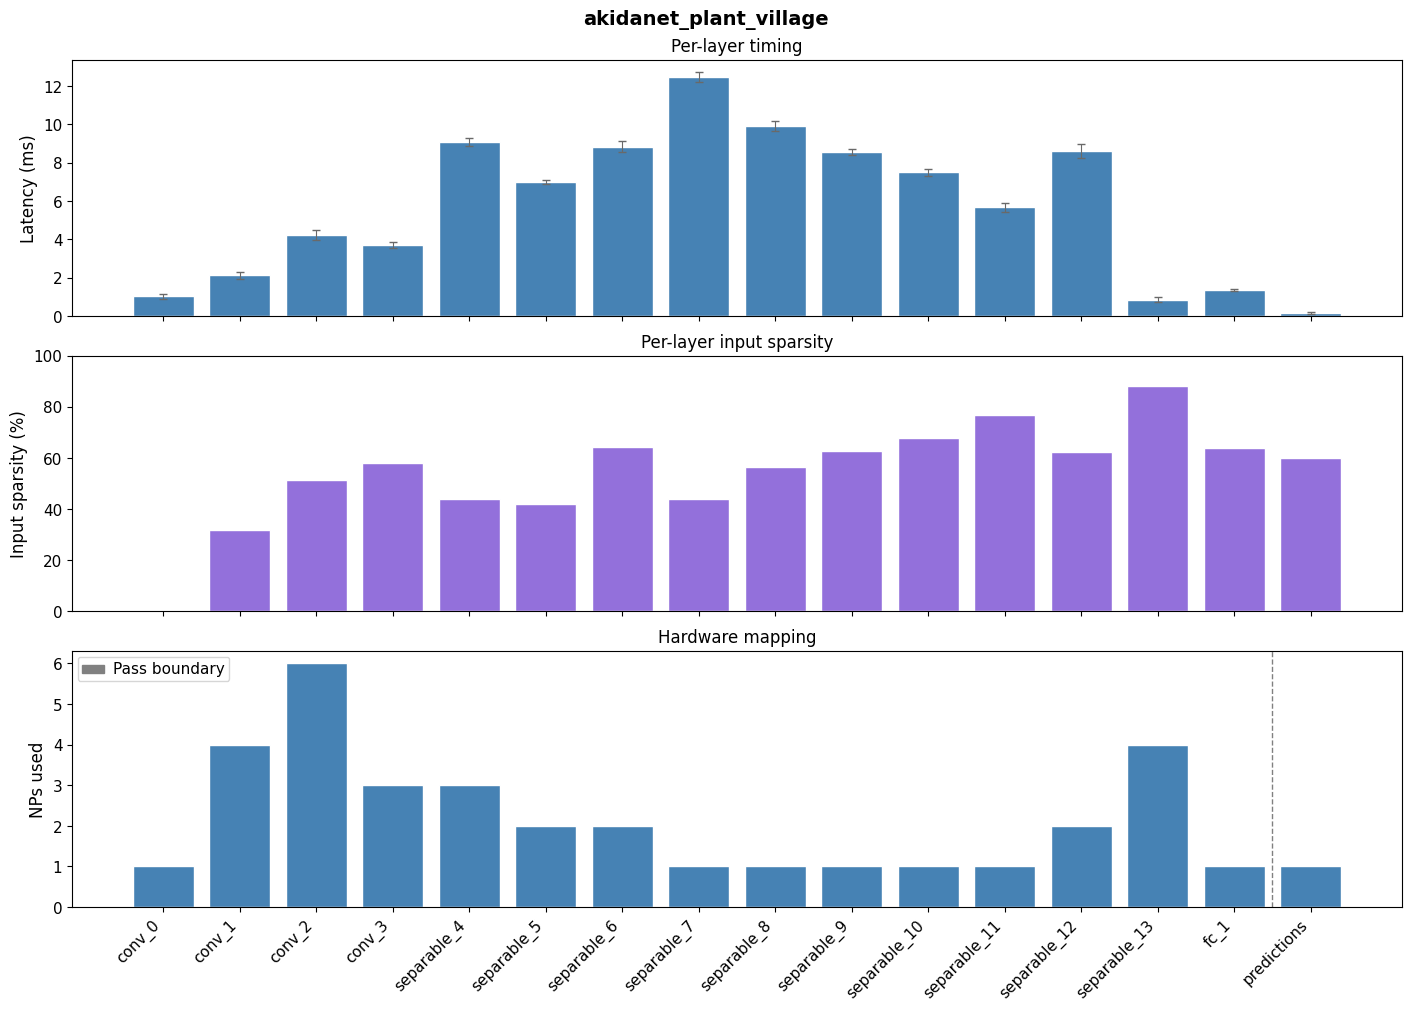

In [ ]:
if device is not None:
    plot_per_layer_results(per_layer_results, akida_model, sparsity_dict,
                           model_name='akidanet_plant_village',
                           savepath='benchmark_results_layers.png')

## Summary

The table below compares validation accuracy across the three model variants.
The goal is that QAT and Akida accuracy remain close to the float baseline.

In [ ]:
print('PlantVillage results')
print('=' * 40)
print(f'  Float accuracy:     {float_acc * 100:.2f}%')
print(f'  QAT accuracy:       {qat_acc * 100:.2f}%')
print(f'  Akida accuracy:     {akida_acc * 100:.2f}%')

PlantVillage results
  Float accuracy:     99.61%
  QAT accuracy:       99.43%
  Akida accuracy:     99.43%
